In [ ]:
import numpy as np
import matplotlib.pyplot as plt

from rfmodel.core.signal import Signal
from rfmodel.comms.QAM_modulator import QAMModulator, QAMParams
from rfmodel.plot_utils import 
from rfmodel.comms.OFDM_block import OFDMModulator, OFDMParams
from rfmodel.plot_utils import plot_constellation, plot_bits, plot_constellation_with_bits, plot_ofdm_frequency_bins_centered, plot_time_signal, plot_spectrum, reconstruct_one_ofdm_symbol_freq

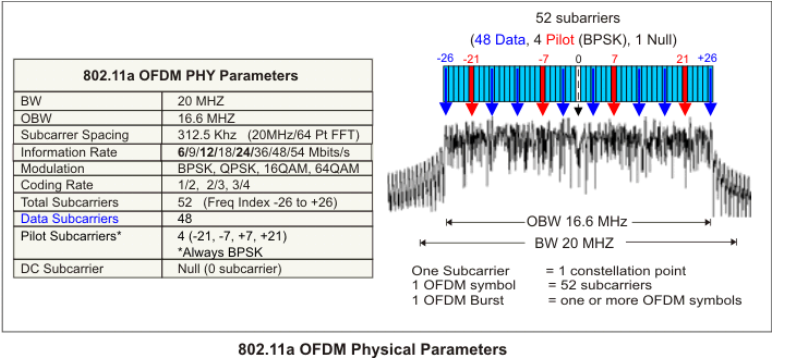

Number of bits: 1248
Expected QAM symbols: 208


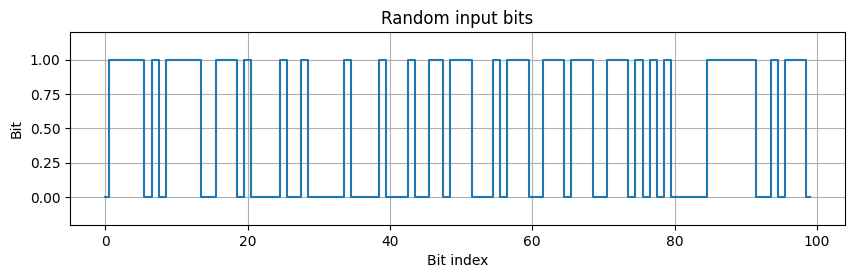

In [26]:
# --------------------------------------------------
# Parameters
# --------------------------------------------------
rng = np.random.default_rng(0)

M = 64
bits_per_symbol = int(np.log2(M))

fs_hz = 20e6
n_fft = 64
cp_len = 16
n_data_subcarriers = 52
num_ofdm_symbols = 4

n_qam_symbols = num_ofdm_symbols * n_data_subcarriers

# --------------------------------------------------
# Generate bits
# --------------------------------------------------
bits = rng.integers(
    0, 2,
    size=n_qam_symbols * bits_per_symbol,
    dtype=np.uint8
)

sig_bits = Signal(
    x=bits,
    fs_hz=fs_hz,
    fc_hz=0.0,
    meta={}
)

print("Number of bits:", len(bits))
print("Expected QAM symbols:", n_qam_symbols)

plot_bits(bits, n_bits=100, title="Random input bits")

Actual QAM symbols: 208
Average QAM symbol power: 1.0100732600732603


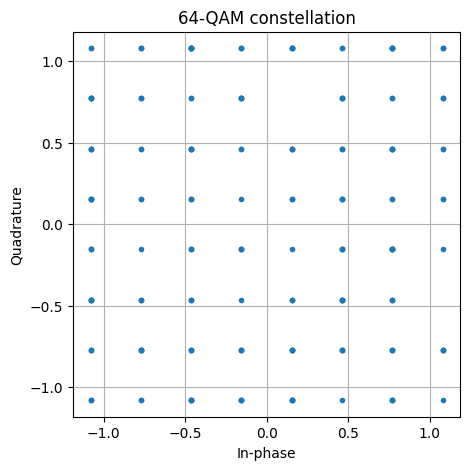

In [27]:
# --------------------------------------------------
# QAM modulation
# --------------------------------------------------
qam = QAMModulator(
    "qam1",
    QAMParams(
        M=M,
        gray_map=False,
        unit_average_power=True,
    )
)

sig_qam = qam.process(sig_bits)
qam_symbols = sig_qam.x

print("Actual QAM symbols:", len(qam_symbols))
print("Average QAM symbol power:", np.mean(np.abs(qam_symbols) ** 2))

plot_constellation(qam_symbols, title="64-QAM constellation")

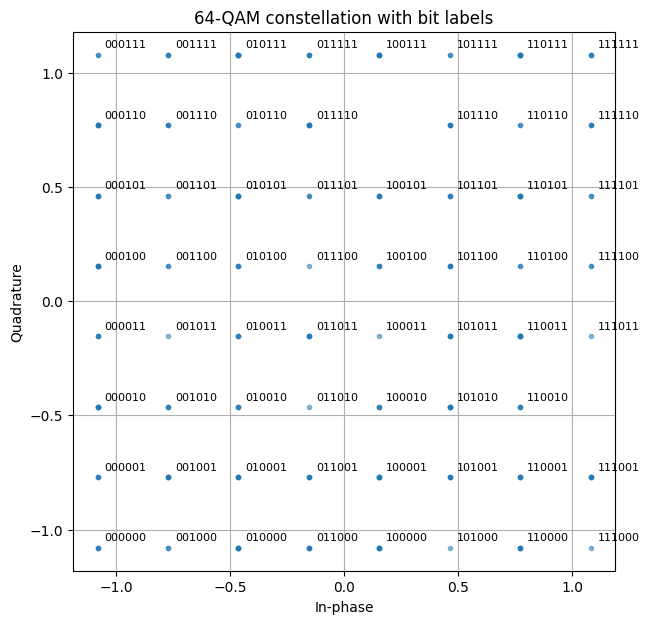

In [28]:
plot_constellation_with_bits(
    sig_qam.x,
    bits=sig_bits.x,
    bits_per_symbol=bits_per_symbol,
    title="64-QAM constellation with bit labels",
)

In [29]:
# --------------------------------------------------
# OFDM modulation
# --------------------------------------------------
ofdm = OFDMModulator(
    "ofdm1",
    OFDMParams(
        n_fft=n_fft,
        cp_len=cp_len,
        n_data_subcarriers=n_data_subcarriers,
        normalize_ifft=True,
        null_dc=True,
    )
)

sig_ofdm = ofdm.process(sig_qam)
tx = sig_ofdm.x

print("OFDM output samples:", len(tx))
print("Expected samples:", num_ofdm_symbols * (n_fft + cp_len))
print("Average OFDM sample power:", np.mean(np.abs(tx) ** 2))
print("Active bins:", sig_ofdm.meta["active_bins"])

OFDM output samples: 320
Expected samples: 320
Average OFDM sample power: 0.8221338269323242
Active bins: [38, 39, 40, 41, 42, 43, 44, 45, 46, 47, 48, 49, 50, 51, 52, 53, 54, 55, 56, 57, 58, 59, 60, 61, 62, 63, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16, 17, 18, 19, 20, 21, 22, 23, 24, 25, 26]


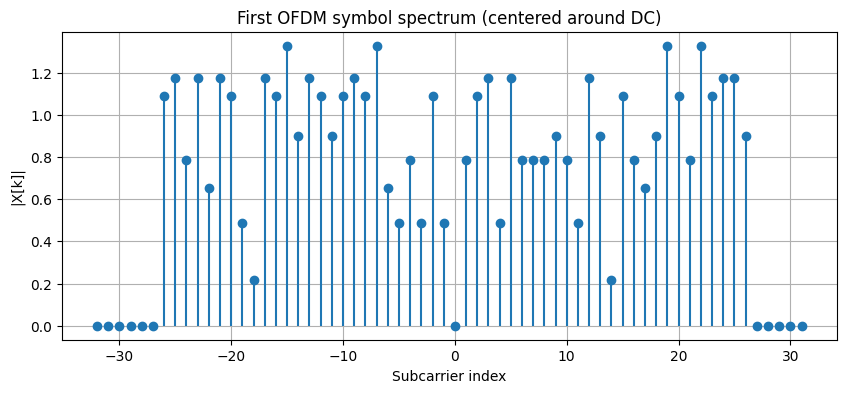

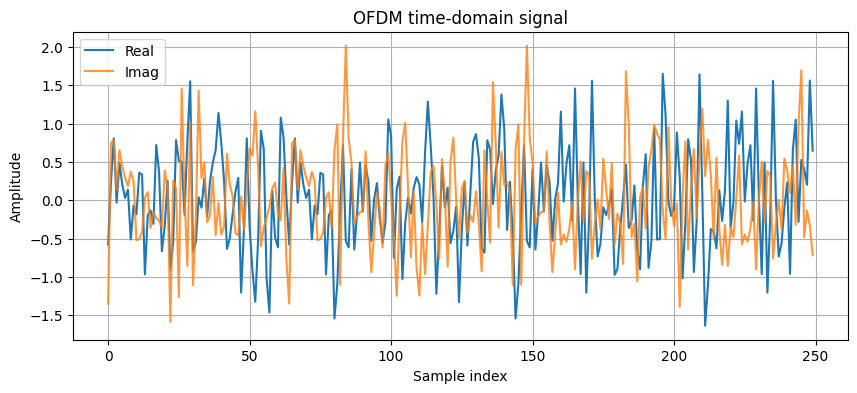

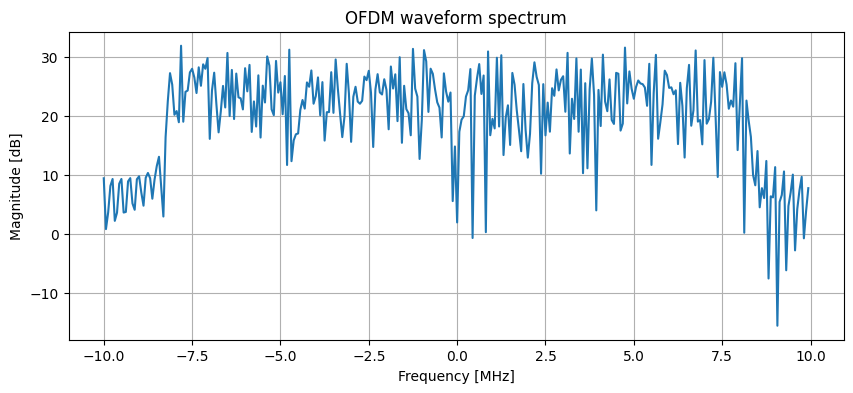

In [30]:

# --------------------------------------------------
# Visualize one OFDM symbol in frequency domain
# --------------------------------------------------
qam_blocks = qam_symbols.reshape(num_ofdm_symbols, n_data_subcarriers)
first_qam_block = qam_blocks[0]

active_bins = np.array(sig_ofdm.meta["active_bins"])
Xk0 = reconstruct_one_ofdm_symbol_freq(first_qam_block, active_bins, n_fft)

plot_ofdm_frequency_bins_centered(Xk0, title="First OFDM symbol spectrum (centered around DC)")

# --------------------------------------------------
# Time-domain OFDM signal
# --------------------------------------------------
plot_time_signal(tx, n_samples=250, title="OFDM time-domain signal")

# --------------------------------------------------
# Spectrum of full OFDM waveform
# --------------------------------------------------
plot_spectrum(tx, fs_hz=fs_hz, title="OFDM waveform spectrum")